# Quantitive Comparison of the baseline methods with Dueling DRL


## Research-Grade Visualization


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 7),
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.linewidth": 1.2,
    }
)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

## Merge the CSV Files


In [2]:
import pandas as pd
import os
from functools import reduce


def merge_csvs_column_wise(file_list, output_filename=None):
    """
    Reads a list of CSV files and merges them column-wise
    based on their shared metric names.
    """
    dataframes = []

    for file in file_list:
        if os.path.exists(file):
            df = pd.read_csv(file)

            # Rename the first column to 'Metric' so all dataframes have a common key
            df = df.rename(columns={df.columns[0]: "Metric"})

            dataframes.append(df)
        else:
            print(f"Warning: File '{file}' not found.")

    if not dataframes:
        print("No data was found to merge.")
        return None

    # Merge all dataframes side-by-side sequentially on the 'Metric' column
    # 'outer' join ensures no metrics are lost if some models don't have them
    merged_df = reduce(
        lambda left, right: pd.merge(left, right, on="Metric", how="outer"), dataframes
    )

    # Optionally save to a new CSV
    if output_filename:
        merged_df.to_csv(output_filename, index=False)
        print(f"Successfully saved merged data to {output_filename}")

    return merged_df


# List of your specific files
csv_files = [
    "./results/PPO_df.csv",
    "./results/SAC_df.csv",
    "./results/TD3_df.csv",
    "./results/Continuous_DQN_df.csv",
    "./results/Double_DQN_df.csv",
    "./results/CQL_df.csv",
    "./results/Dueling_DRL_df.csv",
]

# Execute the function
merged_col_data = merge_csvs_column_wise(
    csv_files, output_filename="./results/DRL_Metrics_Comparison.csv"
)

Successfully saved merged data to ./results/DRL_Metrics_Comparison.csv


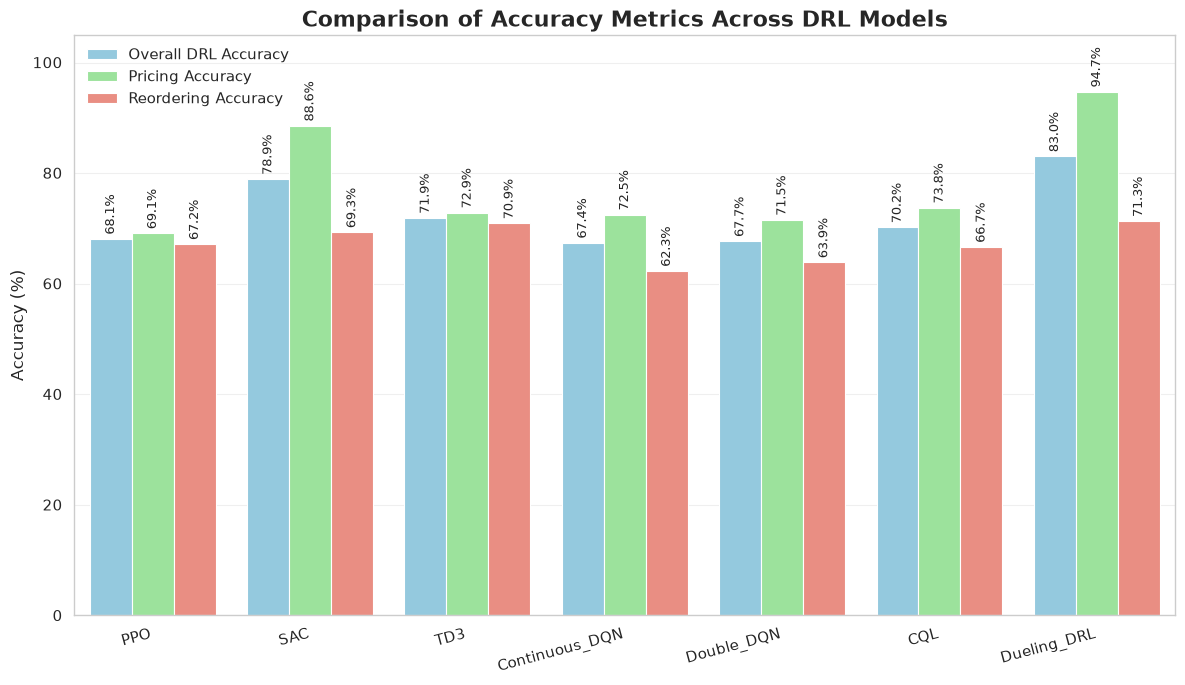

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read data
df = pd.read_csv("./results/DRL_Metrics_Comparison.csv")

# Extract relevant metrics
metrics_to_plot = [
    "Pricing Accuracy",
    "Reordering Accuracy",
    "Overall DRL Accuracy",
]

df_filtered = df[df["Metric"].isin(metrics_to_plot)].copy()

# Models are all columns except "Metric"
models = list(df.columns[1:])

# Rearrange the columns so Dueling_DRL is last
if "Dueling_DRL" in models:
    models.remove("Dueling_DRL")
    models.append("Dueling_DRL")

# Reorder dataframe columns
df_filtered = df_filtered[["Metric"] + models]


# Convert percentage strings to float
def clean_pct(val):
    if isinstance(val, str):
        return float(val.replace("%", "").strip())
    return float(val)


for model in models:
    df_filtered[model] = df_filtered[model].apply(clean_pct)

# Convert from wide format to long format
df_long = df_filtered.melt(id_vars="Metric", var_name="Model", value_name="Accuracy")

# Plot
ax = sns.barplot(
    data=df_long,
    x="Model",
    y="Accuracy",
    hue="Metric",
    palette=["skyblue", "lightgreen", "salmon"],
)

# Labels and title
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_xlabel("")
ax.set_title(
    "Comparison of Accuracy Metrics Across DRL Models",
    fontsize=16,
    fontweight="bold",
)

plt.xticks(rotation=15, ha="right")
plt.ylim(0, 105)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        rotation=90,
        fontsize=9,
    )

plt.legend(title="", loc="upper left")
plt.tight_layout()
plt.savefig("./plots/accuracy_comparison.pdf", dpi=1200)
plt.show()

                       Metric Model  Fidelity (%)
0  Pricing Fidelity (Depth=3)   PPO         39.89
1  Reorder Fidelity (Depth=3)   PPO         14.06
2  Pricing Fidelity (Depth=3)   SAC         87.38
3  Reorder Fidelity (Depth=3)   SAC         21.46
4  Pricing Fidelity (Depth=3)   TD3         28.69
Index(['Metric', 'Model', 'Fidelity (%)'], dtype='str')


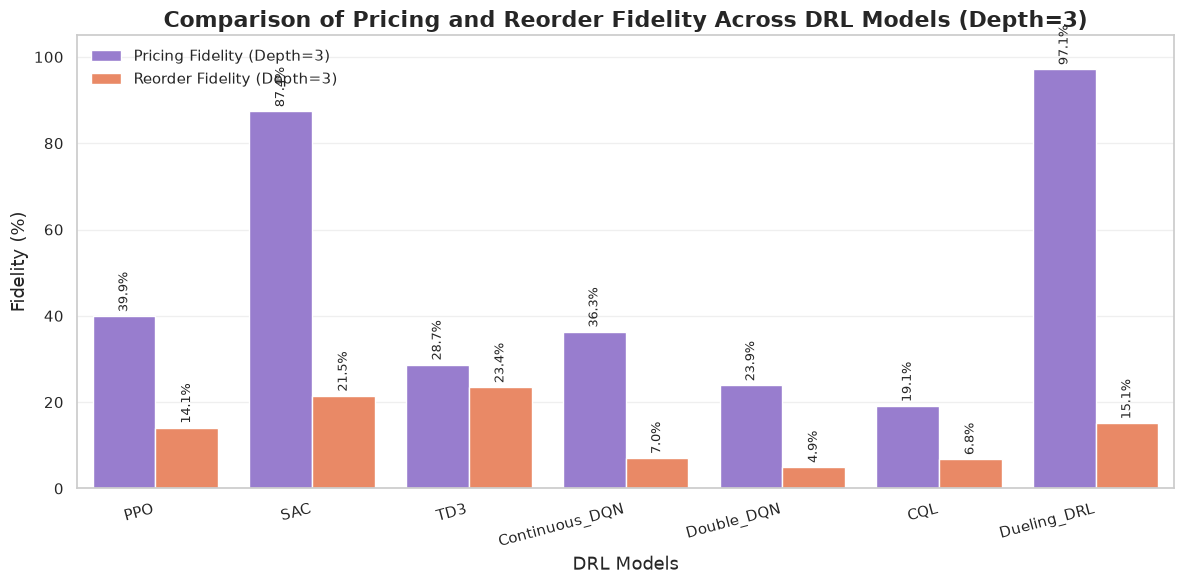

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting style
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv("./results/DRL_Metrics_Comparison.csv")

# Fidelity metrics to plot
fidelity_metrics = [
    "Pricing Strategy Tree Fidelity (Depth=3)",
    "Reorder Strategy Tree Fidelity (Depth=3)",
]

# Filter the required rows
df_filtered = df[df["Metric"].isin(fidelity_metrics)].copy()

# Model order
models = list(df.columns[1:])

# Move Dueling_DRL to the end
if "Dueling_DRL" in models:
    models.remove("Dueling_DRL")
    models.append("Dueling_DRL")

# Reorder dataframe columns
df_filtered = df_filtered[["Metric"] + models]


# Convert percentage strings to float
def clean_pct(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str):
        return float(val.replace("%", "").strip())
    return float(val)


for model in models:
    df_filtered[model] = df_filtered[model].apply(clean_pct)

# Convert from wide to long format
df_melted = df_filtered.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Fidelity (%)",
)

# Rename legend labels
df_melted["Metric"] = (
    df_melted["Metric"]
    .str.replace(" Strategy Tree Fidelity (Depth=3)", "", regex=False)
    .replace(
        {
            "Pricing": "Pricing Fidelity (Depth=3)",
            "Reorder": "Reorder Fidelity (Depth=3)",
        }
    )
)

# Preserve model order
df_melted["Model"] = pd.Categorical(
    df_melted["Model"],
    categories=models,
    ordered=True,
)

# Sort according to the categorical order
df_melted = df_melted.sort_values("Model")

# Verify columns (optional)
print(df_melted.head())
print(df_melted.columns)

# Create figure
plt.figure(figsize=(12, 6))

# Plot
ax = sns.barplot(
    data=df_melted,
    x="Model",  # <-- Fixed here
    y="Fidelity (%)",
    hue="Metric",
    palette=["mediumpurple", "coral"],
)

# Labels
ax.set_title(
    "Comparison of Pricing and Reorder Fidelity Across DRL Models (Depth=3)",
    fontsize=16,
    fontweight="bold",
)

ax.set_xlabel("DRL Models", fontsize=13)
ax.set_ylabel("Fidelity (%)", fontsize=13)

plt.xticks(rotation=15, ha="right")
plt.ylim(0, 105)

plt.legend(title="", loc="upper left")

# Add value labels
for container in ax.containers:
    labels = [f"{v:.1f}%" if not np.isnan(v) else "" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90,
        fontsize=9,
    )

# Save and show
plt.tight_layout()
plt.savefig("./plots/fidelity_comparison.pdf", dpi=1200, bbox_inches="tight")
plt.show()

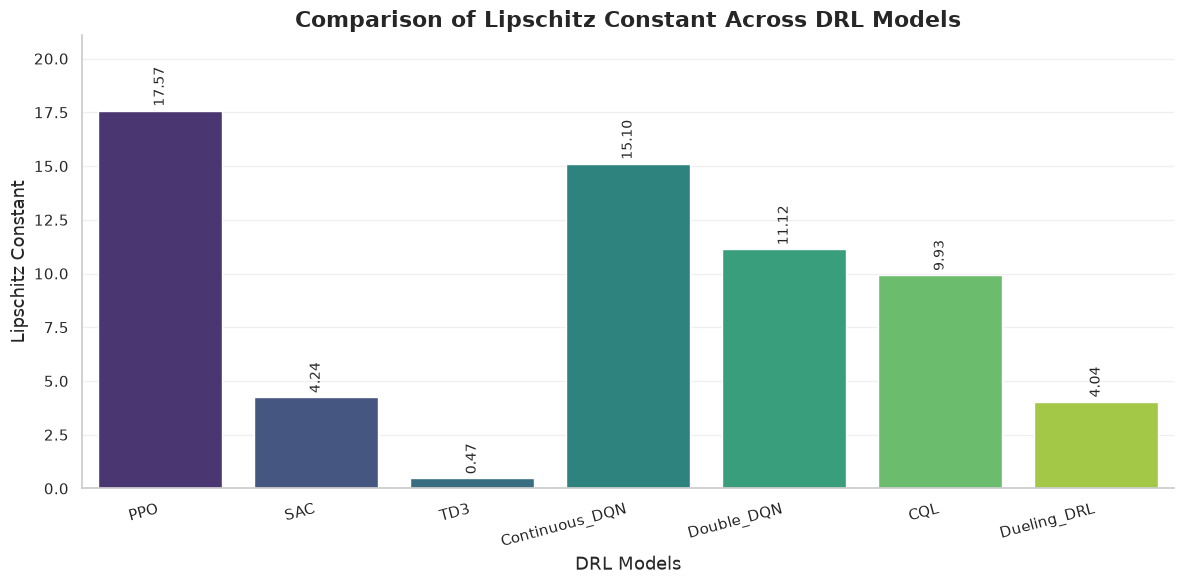

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create output directory
os.makedirs("./plots", exist_ok=True)
os.makedirs("./results", exist_ok=True)

# Set plotting style
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv("./results/DRL_Metrics_Comparison.csv")

# Metric to plot
target_metrics = ["Lipschitz Constant"]

# Filter required row
df_filtered = df[df["Metric"].isin(target_metrics)].copy()

# Model order
models = list(df.columns[1:])

# Move Dueling_DRL to the end
if "Dueling_DRL" in models:
    models.remove("Dueling_DRL")
    models.append("Dueling_DRL")

# Reorder columns
df_filtered = df_filtered[["Metric"] + models]


# Convert values to float
def clean_val(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str):
        return float(val.replace("%", "").strip())
    return float(val)


for model in models:
    df_filtered[model] = df_filtered[model].apply(clean_val)

# Convert from wide to long format
df_melted = df_filtered.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Lipschitz Constant",
)

# Preserve model order
df_melted["Model"] = pd.Categorical(
    df_melted["Model"],
    categories=models,
    ordered=True,
)

df_melted = df_melted.sort_values("Model")

# Color palette (one color per model)
colors = sns.color_palette("viridis", n_colors=len(df_melted["Model"].unique()))

# Create figure
plt.figure(figsize=(12, 6))

# Plot
ax = sns.barplot(
    data=df_melted,
    x="Model",
    y="Lipschitz Constant",
    hue="Model",  # Different color for each model
    palette=colors,
    dodge=False,
    legend=False,
)

# Title and labels
ax.set_title(
    "Comparison of Lipschitz Constant Across DRL Models",
    fontsize=16,
    fontweight="bold",
)

ax.set_xlabel("DRL Models", fontsize=13)
ax.set_ylabel("Lipschitz Constant", fontsize=13)

# Rotate x-axis labels
plt.xticks(rotation=15, ha="right")

# Add headroom for labels
max_val = df_melted["Lipschitz Constant"].max()
plt.ylim(0, max_val * 1.20)

# Add value labels
for container in ax.containers:
    labels = [f"{v:.2f}" if not np.isnan(v) else "" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=10,
        rotation=90,
    )

# Remove top/right spines
sns.despine()

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    "./plots/lipschitz_comparison.pdf",
    dpi=1200,
    bbox_inches="tight",
)

plt.show()